# Categoricality says nothing about whether regions form types

A region's neurons are an elongated cloud in tuning-shape space. `amount` sets how bimodal
it is along its long axis -- how categorical the region is. `kind` ($\psi$) sets that axis's
orientation -- what the region is categorical *about*.

**Scenario 1 -- a continuum.** Regions vary continuously: `amount` sweeps from 0 to ~1 and
`kind` sweeps with it. The distribution of per-region categoricality is **spread out**, and
in region space the regions lie on a continuum with no types in it.

**Scenario 2 -- three kinds.** **No region is categorical at all** ($a$ = 0, so every
per-region $z$ sits at zero), but `kind` takes three discrete values, so region space
contains three clean clusters.

Read the first column and you learn nothing about the third.

### Why `amount` and `kind` are swept together in scenario 1

The generator holds a region's total spread fixed as `amount` changes, so the second moment
of its weights -- which is what a Procrustes comparison of regions sees -- depends on `kind`
and not on `amount`. Sweeping `amount` alone would spread the categoricality histogram while
leaving region space almost unchanged; sweeping `kind` alone would give the continuum but a
flat histogram. Scenario 1 needs both, and they are two visible consequences of one
underlying gradient.

### Two choices in scenario 1 that are not arbitrary

Its regions are **sampled** along the gradient rather than evenly spaced: an evenly spaced
lattice is itself non-Gaussian, and the region-space test would report that regularity as
structure.

And it sweeps only part of the $\psi$ range. Procrustes distance is a nonlinear function of
$\psi$, so a wide sweep puts the regions on a strongly **curved** arc -- and the
silhouette-versus-Gaussian test detects departure from a Gaussian, which curvature is. Over
the full range this simulation returns $p$ = 0.01 for a continuum containing no types
whatsoever. **That is a limitation of the test, not evidence of types**, and it is worth
knowing: a strongly curved continuum of regions can be reported as lumpy. Scenario 1 stays
in the near-straight regime so the intended contrast is the only thing on show.

### The region-space test

Regions are embedded by **classical MDS -- PCA of the Procrustes distances** (deterministic,
and its axes come out ordered by variance, unlike SMACOF). The statistic is the best
silhouette over $k$; the null is Gaussians matched to that embedding's mean and covariance.
A continuum is *not* lumpy in this sense -- a line of points and a Gaussian blob score
alike -- while genuine types are.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Patch
from scipy import stats

# Anchor on the directory holding the simulation modules, so the notebook runs
# whether the kernel starts in clustering-simulation or at the repo root.
# Path.cwd() alone fails with ModuleNotFoundError from anywhere else.
HERE = next(p for p in (Path.cwd(), Path.cwd() / "clustering-simulation",
                        *Path.cwd().parents)
            if (p / "region_space.py").exists())
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parent))
import region_space as R

OUT = HERE / "results"
OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"svg.fonttype": "none", "text.usetex": False})

# house style; the three-hue set passes the lightness, chroma, CVD (worst dE 22.1)
# and contrast checks, and keeps the two hues used by the other notebooks here
PANEL = 2.1
OBS, NULLC, GREY = "#B22222", "#1F6FB2", "0.75"
KIND_COLORS = ["#B22222", "#1F6FB2", "#E8A33D"]
N_DRAWS = 200
N_DRAWS_CAT = 25   # null draws per region for the categoricality z

print(f"{R.N_REGIONS} regions x {R.N_NEURONS} neurons")

60 regions x 100 neurons


## Running both scenarios

In [2]:
f = OUT / "region_3x4.npz"
if f.exists():
    res = np.load(f, allow_pickle=True)["res"].item()
else:
    res = {}
    for name in ("continuum", "no_gradient", "kinds"):
        X, region, colour = R.scenario(name)
        E = R.pca_embed(R.procrustes_distances(X, region))
        res[name] = dict(
            colour=colour, emb=E,
            z=R.categoricality(X, region, np.random.default_rng(0), N_DRAWS_CAT),
            ct=R.continuum_or_types(E, N_DRAWS),
        )
    np.savez(f, res=np.array(res, dtype=object))

for name, r in res.items():
    print(f"\n=== {name} ===")
    print(f"  categoricality z : {r['z'].min():+.2f} to {r['z'].max():+.2f}"
          f"   (mean {r['z'].mean():+.2f} +/- {r['z'].std():.2f})")
    zz = r["z"]
    print(f"  regions with |z| > 1.96 : {int(np.sum(abs(zz) > 1.96))} of {len(zz)}"
          f"   |z| > {stats.norm.ppf(1 - 0.025 / len(zz)):.2f} (corrected):"
          f" {int(np.sum(abs(zz) > stats.norm.ppf(1 - 0.025 / len(zz))))}")
    print(f"  continuum or types: obs {r['ct']['obs']:.3f}  "
          f"null {r['ct']['null'].mean():.3f} +/- {r['ct']['null'].std():.3f}"
          f"   z = {r['ct']['z']:+.2f}   p = {r['ct']['p']:.3f}")


=== continuum ===
  categoricality z : -1.82 to +9.97   (mean +1.81 +/- 2.57)
  regions with |z| > 1.96 : 20 of 60   |z| > 3.34 (corrected): 14
  continuum or types: obs 0.309  null 0.287 +/- 0.025   z = +0.88   p = 0.199

=== no_gradient ===
  categoricality z : -1.40 to +11.79   (mean +1.85 +/- 2.53)
  regions with |z| > 1.96 : 19 of 60   |z| > 3.34 (corrected): 15
  continuum or types: obs 0.288  null 0.292 +/- 0.026   z = -0.17   p = 0.557

=== kinds ===
  categoricality z : -1.60 to +11.51   (mean +1.81 +/- 2.50)
  regions with |z| > 1.96 : 20 of 60   |z| > 3.34 (corrected): 14
  continuum or types: obs 0.721  null 0.396 +/- 0.033   z = +9.83   p = 0.005


## Is there a gradient along the region cloud?

Rows 1 and 2 give the same categoricality distribution and the same verdict in region space
(one cloud, not types). They differ only in whether categoricality varies *systematically*
along that cloud.

In [3]:
for name in ("continuum", "no_gradient"):
    r = res[name]
    rr = stats.spearmanr(r["z"], r["emb"][:, 0])
    print(f"{name:>12}: rho(categoricality, region PC1) = {abs(rr.statistic):.2f}"
          f"   p = {rr.pvalue:.1e}")

   continuum: rho(categoricality, region PC1) = 0.72   p = 1.1e-10
 no_gradient: rho(categoricality, region PC1) = 0.06   p = 6.6e-01


## The averaging alternative

The same regions, put in a common space a different way: average each region's neurons into
one tuning vector and PCA across regions -- the analysis of Posani et al.'s Fig. 2c. It is
essentially free to compute (no pairwise Procrustes), and it keeps only the first moment.

In [4]:
emb_mean = {}
for name in ("continuum", "no_gradient", "kinds"):
    X, region, _ = R.scenario(name)
    emb_mean[name] = R.mean_embed(X, region)

rho_mean = stats.spearmanr(res["continuum"]["colour"], emb_mean["continuum"][:, 0])
rho_proc = stats.spearmanr(res["continuum"]["colour"], res["continuum"]["emb"][:, 0])
print(f"continuum: |rho(PC1, position)|   averaged {abs(rho_mean.statistic):.2f}"
      f"  (p = {rho_mean.pvalue:.2f})   vs Procrustes {abs(rho_proc.statistic):.2f}")

c, E = res["kinds"]["colour"], emb_mean["kinds"]
sep = np.mean([np.linalg.norm(E[c == i].mean(0) - E[c == j].mean(0))
               for i in range(R.N_KINDS) for j in range(i + 1, R.N_KINDS)])
within = np.mean([E[c == k].std(0).mean() for k in range(R.N_KINDS)])
print(f"kinds    : centroid separation {sep:.3f} vs within-kind spread {within:.3f}"
      "   -> the kinds overlap")

continuum: |rho(PC1, position)|   averaged 0.04  (p = 0.78)   vs Procrustes 0.96
kinds    : centroid separation 0.049 vs within-kind spread 0.126   -> the kinds overlap


## Example regions in shape space

What the two scenarios look like at the level of a single region. Each point is one neuron,
placed by its two shape coordinates -- skew and width. Nothing new is computed here: the
simulated tuning curves are simply projected back onto the two shape modes they were built
from.

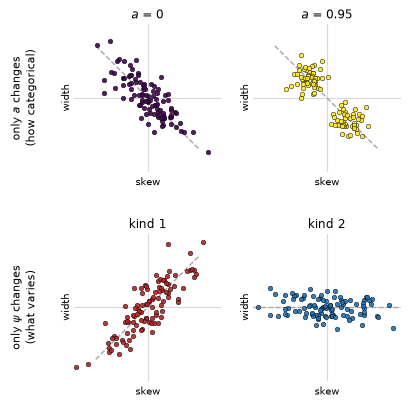

In [5]:
# X = MEAN + SCALE * W @ MODES, and MODES is orthonormal, so the neurons'
# shape coordinates come straight back out.  Mode 2 increases with the von Mises
# concentration kappa (r = +0.99), i.e. with NARROWER tuning, so it is negated
# here to give a true width axis (r = +0.98 with the measured circular s.d.).
def shape_coords(X):
    W = (X - R.MEAN) @ R.MODES.T / R.SCALE
    return np.c_[W[:, 0], -W[:, 1]]        # (skew, width)


# Four example regions generated directly, so that each row varies ONE knob.
# Row 1 holds psi fixed and changes a; row 2 holds a = 0 and changes psi.
PSI_ROW1 = R.PSI                                   # +45 deg, fixed across row 1
KIND_PSI = np.linspace(-R.PSI, R.PSI, R.N_KINDS)   # the three kinds

amounts = [0.0, 0.95, 0.0, 0.0]
psis_ex = [PSI_ROW1, PSI_ROW1, KIND_PSI[0], KIND_PSI[1]]
Xex, regex = R.simulate(amounts, psis_ex, seed=1)
Wex = shape_coords(Xex)

cmap = plt.get_cmap("viridis")
titles = ["$a$ = 0", "$a$ = 0.95", "kind 1", "kind 2"]
cols = [cmap(0.0), cmap(1.0), KIND_COLORS[0], KIND_COLORS[1]]
rowlab = ["only $a$ changes\n(how categorical)", "only $\\psi$ changes\n(what varies)"]

clouds = [Wex[regex == i] - Wex[regex == i].mean(0) for i in range(4)]
lim = 1.12 * np.percentile(np.abs(np.concatenate(clouds)), 99.5)

fig, axes = plt.subplots(2, 2, figsize=(2 * PANEL, 2 * PANEL))
for i, ax in enumerate(axes.ravel()):
    P = clouds[i]
    u = np.array([np.cos(psis_ex[i]), -np.sin(psis_ex[i])])   # y is flipped
    ax.axhline(0, color="0.85", lw=0.8, zorder=0)
    ax.axvline(0, color="0.85", lw=0.8, zorder=0)
    ax.plot([-lim * u[0], lim * u[0]], [-lim * u[1], lim * u[1]],
            color="0.65", lw=1, ls="--", zorder=1)
    ax.scatter(P[:, 0], P[:, 1], s=11, facecolor=cols[i], edgecolor="black",
               linewidths=0.35, alpha=0.9, zorder=2)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xticks=[], yticks=[])
    ax.set_xlabel("skew", fontsize=7.5)
    ax.set_ylabel("width", fontsize=7.5, labelpad=2)
    ax.set_title(titles[i], fontsize=8.5, pad=4)
    ax.set_box_aspect(1)
    sns.despine(ax=ax, left=True, bottom=True)

for row in (0, 1):
    axes[row, 0].text(-0.34, 0.5, rowlab[row], fontsize=8, rotation=90,
                      va="center", ha="center", transform=axes[row, 0].transAxes)

fig.tight_layout(w_pad=1.4, h_pad=2.0)
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_examples.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

## Clustering neurons within a region, versus pooling them across regions

The per-region categoricality is matched across the three fields by construction. So if
clustering the **pooled** neurons gives a different answer in the three, that difference can
only come from how the regions are arranged relative to one another -- structure that has
nothing to do with whether any region contains cell types.

The pooled cloud is subsampled to `N_POOL` neurons: silhouette is $O(n^2)$, and the full
6000 would take over an hour across the three fields and their nulls.

              per region (mean z)   pooled (z)
   continuum                 1.81         6.00
 no_gradient                 1.85         6.43
       kinds                 1.81         3.28


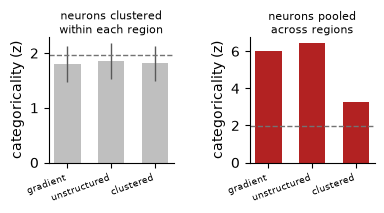

In [6]:
import shapemetrics as sm

N_POOL, N_NULL_POOL = 2000, 100

f = OUT / "pooled_vs_region.npz"
if f.exists():
    pooled = np.load(f, allow_pickle=True)["pooled"].item()
else:
    pooled = {}
    for name in ("continuum", "no_gradient", "kinds"):
        X, region, _ = R.scenario(name)
        rng = np.random.default_rng(0)
        Xp = X[rng.choice(len(X), N_POOL, replace=False)]
        obs = sm.pipeline_silhouette(Xp, k_lim=R.KLIM, n_init=R.NINIT)
        nl = np.array([sm.pipeline_silhouette(sm.curve_gaussian_null(Xp, rng),
                                              k_lim=R.KLIM, n_init=R.NINIT)
                       for _ in range(N_NULL_POOL)])
        pooled[name] = dict(obs=obs, null=nl,
                            z=float((obs - nl.mean()) / (nl.std() + 1e-12)),
                            p=float((np.sum(nl >= obs) + 1) / (len(nl) + 1)))
    np.savez(f, pooled=np.array(pooled, dtype=object))

print(f"{'':>12} {'per region (mean z)':>20} {'pooled (z)':>12}")
for name in ("continuum", "no_gradient", "kinds"):
    print(f"{name:>12} {res[name]['z'].mean():>20.2f} {pooled[name]['z']:>12.2f}")

fig, axes = plt.subplots(1, 2, figsize=(2 * PANEL, PANEL))
names = ["continuum", "no_gradient", "kinds"]
lab = ["gradient", "unstructured", "clustered"]
x = np.arange(3)

ax = axes[0]
ax.bar(x, [res[n]["z"].mean() for n in names], color=GREY, width=0.6,
       yerr=[res[n]["z"].std() / np.sqrt(len(res[n]["z"])) for n in names],
       error_kw=dict(lw=1, ecolor="0.35"))
ax.axhline(1.96, color="0.45", lw=1, ls="--")
ax.set(xticks=x, ylabel="categoricality (z)")
ax.set_xticklabels(lab, fontsize=6.5, rotation=20, ha="right")
ax.set_title("neurons clustered\nwithin each region", fontsize=8, pad=3)
ax.set_box_aspect(1); sns.despine(ax=ax)

ax = axes[1]
ax.bar(x, [pooled[n]["z"] for n in names], color=OBS, width=0.6)
ax.axhline(1.96, color="0.45", lw=1, ls="--")
ax.set(xticks=x, ylabel="categoricality (z)")
ax.set_xticklabels(lab, fontsize=6.5, rotation=20, ha="right")
ax.set_title("neurons pooled\nacross regions", fontsize=8, pad=3)
ax.set_box_aspect(1); sns.despine(ax=ax)

fig.tight_layout(w_pad=1.8)
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"pooled_vs_region.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

## The figure

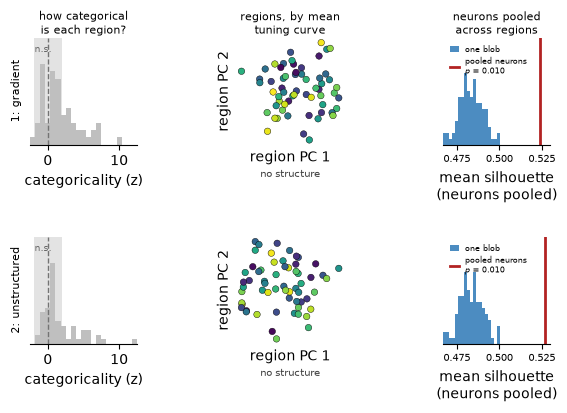

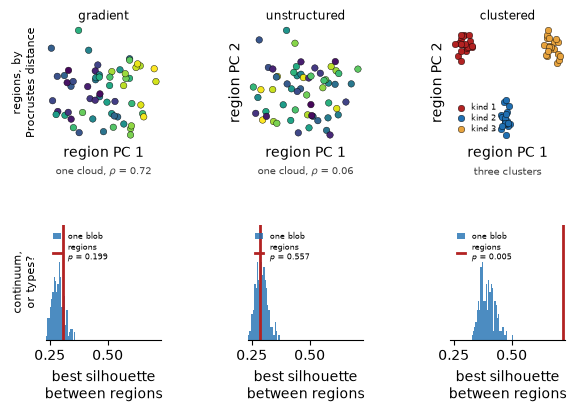

In [7]:
ROWS = [("continuum", res["continuum"], "1: gradient"),
        ("no_gradient", res["no_gradient"], "2: unstructured"),
        ("kinds", res["kinds"], "3: clustered")]
TITLE = {"continuum": "gradient", "no_gradient": "unstructured",
         "kinds": "clustered"}

# shared bins so the categoricality histograms are directly comparable
allz = np.concatenate([r["z"] for _, r, _ in ROWS])
ZBINS = np.linspace(np.floor(allz.min()) - .5, np.ceil(allz.max()) + .5, 22)


def plot_hist(ax, r):
    ax.hist(r["z"], bins=ZBINS, color=GREY)
    ax.axvline(0, color="0.45", lw=1, ls="--")
    ax.set_xlim(ZBINS[0], ZBINS[-1])
    ylo, yhi = ax.get_ylim(); ax.set_ylim(0, yhi * 1.26)
    ax.axvspan(-1.96, 1.96, color="0.89", lw=0, zorder=0)
    ax.text(-1.85, yhi * 1.12, "n.s.", ha="left", va="center", fontsize=6.5,
            color="0.4")
    ax.set(xlabel="categoricality (z)", yticks=[])
    ax.set_box_aspect(1); sns.despine(ax=ax, left=True)


# rows 1-2 are coloured by the RANK of each region's categoricality: z is
# strongly right-skewed, so a linear scale hides the ordering
def plot_regions(ax, E, name, r, legend=False):
    if name == "kinds":
        for k in range(R.N_KINDS):
            m = r["colour"] == k
            ax.scatter(E[m, 0], E[m, 1], c=KIND_COLORS[k], s=22,
                       edgecolor="black", linewidths=0.3, label=f"kind {k + 1}")
        if legend:
            ax.legend(frameon=False, fontsize=5.6, loc="best", handlelength=1.0,
                      scatterpoints=1, labelspacing=0.25)
    else:
        ax.scatter(E[:, 0], E[:, 1], c=stats.rankdata(r["z"]) / len(r["z"]),
                   cmap="viridis", s=22, edgecolor="black", linewidths=0.3,
                   vmin=0, vmax=1)
    ax.set(xlabel="region PC 1", ylabel="region PC 2", xticks=[], yticks=[])
    ax.set_box_aspect(1); sns.despine(ax=ax, left=True, bottom=True)


# the three silhouette histograms share bins AND range, so the panels are
# directly comparable: the observed value for the three kinds sits far to the
# right of where the other two fall
_v = np.concatenate([np.r_[r["ct"]["null"], r["ct"]["obs"]] for _, r, _ in ROWS])
BINW = min(np.ptp(r["ct"]["null"]) for _, r, _ in ROWS) / 22
SBINS = np.arange(np.floor(_v.min() / BINW) * BINW, _v.max() + 2 * BINW, BINW)


def plot_test(ax, r):
    ct = r["ct"]
    ax.hist(ct["null"], bins=SBINS, color=NULLC, alpha=0.8, label="one blob")
    ax.set_xlim(SBINS[0], SBINS[-1])
    ax.axvline(ct["obs"], color=OBS, lw=2, label=f"regions\n$p$ = {ct['p']:.3f}")
    ax.set(xlabel="best silhouette\nbetween regions", yticks=[])
    ylo, yhi = ax.get_ylim(); ax.set_ylim(ylo, yhi * 1.42)
    ax.legend(frameon=False, fontsize=5.8, loc="upper left", handlelength=1.0,
              labelspacing=0.25)
    ax.set_box_aspect(1); sns.despine(ax=ax, left=True)


# ============ FIGURE 1: what you can see at the neuron level ==============
# the pooled panels share bins and range, as the region-space tests do
_pv = np.concatenate([np.r_[pooled[n]["null"], pooled[n]["obs"]]
                      for n, _, _ in ROWS[:2]])
PBINW = min(np.ptp(pooled[n]["null"]) for n, _, _ in ROWS[:2]) / 18
PBINS = np.arange(np.floor(_pv.min() / PBINW) * PBINW, _pv.max() + 2 * PBINW, PBINW)

fig, axes = plt.subplots(2, 3, figsize=(3 * PANEL, 2 * PANEL))
for row, (name, r, lab) in enumerate(ROWS[:2]):
    plot_hist(axes[row, 0], r)
    axes[row, 0].set_ylabel(lab, fontsize=8, labelpad=6)
    plot_regions(axes[row, 1], emb_mean[name], name, r)
    axes[row, 1].text(0.5, -0.30, "no structure", fontsize=7, color="0.25",
                      ha="center", transform=axes[row, 1].transAxes)

    ax = axes[row, 2]
    pl = pooled[name]
    ax.hist(pl["null"], bins=PBINS, color=NULLC, alpha=0.8, label="one blob")
    ax.axvline(pl["obs"], color=OBS, lw=2,
               label=f"pooled neurons\n$p$ = {pl['p']:.3f}")
    ax.set_xlim(PBINS[0], PBINS[-1])
    # the range is narrow, so the default tick labels run into each other
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.tick_params(axis="x", labelsize=7)
    ax.set(xlabel="mean silhouette\n(neurons pooled)", yticks=[])
    ylo, yhi = ax.get_ylim(); ax.set_ylim(ylo, yhi * 1.42)
    ax.legend(frameon=False, fontsize=5.8, loc="upper left", handlelength=1.0,
              labelspacing=0.25)
    ax.set_box_aspect(1); sns.despine(ax=ax, left=True)

    if row == 0:
        axes[row, 0].set_title("how categorical\nis each region?", fontsize=8, pad=3)
        axes[row, 1].set_title("regions, by mean\ntuning curve", fontsize=8, pad=3)
        axes[row, 2].set_title("neurons pooled\nacross regions", fontsize=8, pad=3)
fig.tight_layout(w_pad=1.6, h_pad=2.6)
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_neuron_level.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

# ============ FIGURE 2: the same three fields in region space =============
fig, axes = plt.subplots(2, 3, figsize=(3 * PANEL, 2 * PANEL))
for col, (name, r, _) in enumerate(ROWS):
    plot_regions(axes[0, col], r["emb"], name, r, legend=(name == "kinds"))
    axes[0, col].set_title(TITLE[name], fontsize=8.5, pad=4)
    rho = abs(stats.spearmanr(r["z"], r["emb"][:, 0]).statistic)
    axes[0, col].text(0.5, -0.30,
                      "three clusters" if name == "kinds"
                      else f"one cloud, $\\rho$ = {rho:.2f}",
                      fontsize=7, color="0.25", ha="center",
                      transform=axes[0, col].transAxes)
    plot_test(axes[1, col], r)
axes[0, 0].set_ylabel("regions, by\nProcrustes distance", fontsize=8, labelpad=6)
axes[1, 0].set_ylabel("continuum,\nor types?", fontsize=8, labelpad=6)
fig.tight_layout(w_pad=1.6, h_pad=3.0)
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_space.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

## The combined figure

All of the above in one 2 x 9 panel: three example regions in two views each
(columns 1-3), what the neuron level shows for a gradient and for a random
arrangement (columns 4-6), and the same three fields in region space (columns 7-9).

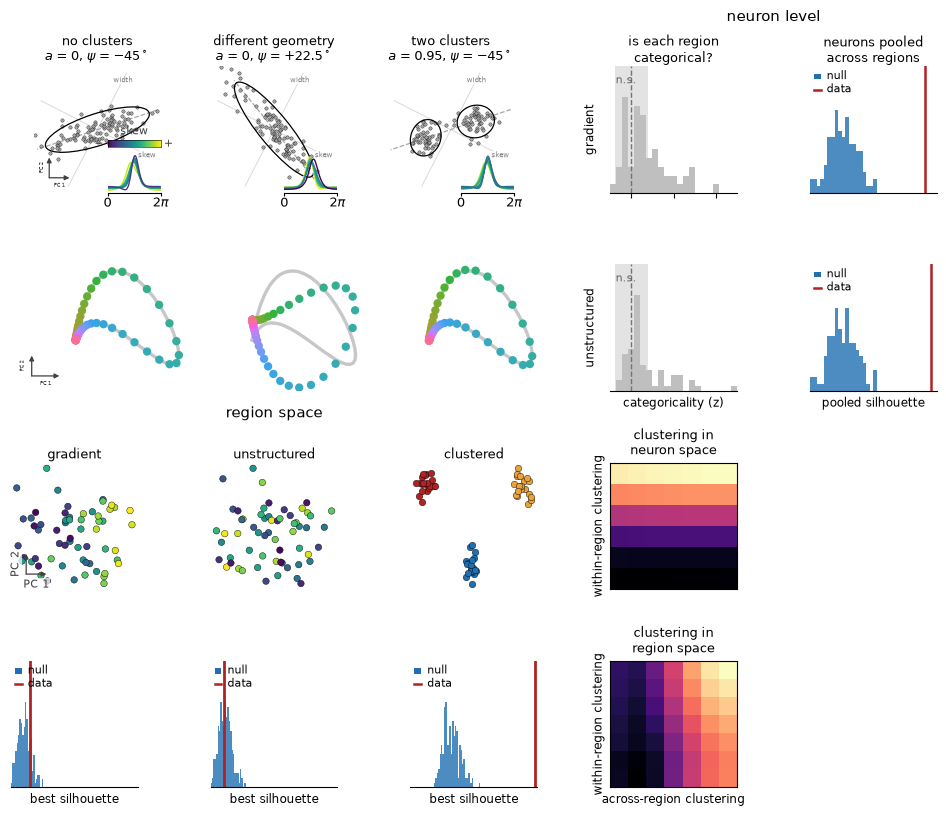

In [8]:
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA

PC = 1.95
# 4 x 5.  Examples (rows 1-2, cols 1-3) with the neuron level beside them
# (cols 4-5), and region space directly beneath the examples (rows 3-4,
# cols 1-3).  The bottom-right 2 x 2 is left empty.
fig, axes = plt.subplots(4, 5, figsize=(5 * PC, 4.1 * PC))
HM_AXES = []
TUNING_AXES = []


# ---- columns 1-3: three example regions, two views of each ---------------
# Top row, left to right: reference | change psi | change a.  So panel 2 differs
# from panel 1 in what the region is categorical ABOUT, and panel 3 differs from
# panel 1 in HOW categorical it is.  Bottom row: the same three regions as population
# manifolds -- the object a Procrustes distance actually compares.
# The left region is at psi = 22.5 deg against a reference at -45 deg; the pair
# was chosen from the full sweep in psi_sweep.ipynb, where this contrast is
# 10.7x the size of the a-only contrast (a = 0 vs 0.95 at fixed psi, d = 1.46).
# Note the skew/width cross below is regressed rather than assumed -- the PCA
# frame rotates with whatever regions are pooled, so its angle relative to the
# cross is not fixed.
ex_a, ex_psi = [0.0, 0.0, 0.95], [-R.PSI, np.radians(22.5), -R.PSI]
NEX = len(ex_a)
# Second line: the two generator parameters, so the reader can see that each
# panel differs from the first in exactly ONE of them.  Middle changes psi at
# fixed a (geometry moves, clustering does not); right changes a at fixed psi
# (clustering appears, geometry does not).
ETIT = ["no clusters\n$a$ = 0, $\\psi$ = $-45^\\circ$",
        "different geometry\n$a$ = 0, $\\psi$ = $+22.5^\\circ$",
        "two clusters\n$a$ = 0.95, $\\psi$ = $-45^\\circ$"]
# seed 12.  The a-contrast is pure sampling noise -- d(a = 0 vs 0.95) equals the
# floor of drawing the SAME region twice (2.90 vs 2.83 over 40 seeds), so it is
# a draw and not an effect -- but that floor is 2.9 +/- 1.5, wide enough that an
# unlucky draw makes the third manifold visibly miss the reference.
# NOTE the seed is tied to the PANEL ORDER: R.simulate draws the regions in
# sequence from one stream, so reordering them hands each region different
# draws.  Seed 47 gave 13.6x under the old order and only 8.2x under this one.
# For this order seed 12 gives d(psi) = 18.3 against d(a) = 0.62, a 29.6x ratio.
Xe, rege = R.simulate(ex_a, ex_psi, seed=12)

# each neuron placed by the first two PCs of the neurons x conditions matrix.
# One plane is fitted to the three regions pooled, so the panels share axes; a
# per-region PCA would give each panel its own rotation and the psi difference
# between the left pair would disappear into PC 1.
We = PCA(2).fit_transform(Xe)
# where "skew" and "width" point in this PCA plane.  Each is regressed on the
# two PC scores; both come back at R^2 = 1.000 and exactly 90 deg apart, because
# the PCA plane IS the shape-mode plane up to a rotation.
_A = np.c_[We, np.ones(len(We))]
_B = np.linalg.lstsq(_A, shape_coords(Xe), rcond=None)[0][:2]
SHAPE_DIRS = _B / np.linalg.norm(_B, axis=0)          # columns: skew, width

cl = [We[rege == i] - We[rege == i].mean(0) for i in range(NEX)]
elim = 1.05 * np.percentile(np.abs(np.concatenate(cl)), 99.5)

# The manifolds, PCA'd over the NEURON dimension.  Each is centred and scaled to
# unit Frobenius norm so the three panels share one scale, and each panel also
# carries the MIDDLE region's manifold in grey behind it, rotated on by the same
# optimal orthogonal transform a Procrustes distance uses.  Without that the
# panels sit in arbitrary, per-region bases and cannot be compared by eye -- the
# shapes differ by 0.219 (psi) vs 0.036 (a), a 6x gap that is invisible until
# the manifolds are put in register.
def align_to(A, B):
    # rotate/reflect B onto A -- the transform the shape metric optimises over
    U, _, Vt = np.linalg.svd(B.T @ A)
    return B @ (U @ Vt)


MAN = []
for _i in range(NEX):
    _m = PCA(2).fit_transform(Xe[rege == _i].T)
    _m = _m - _m.mean(0)
    MAN.append(_m / np.linalg.norm(_m))
MREF = MAN[0]                       # the reference region is now the FIRST panel
# Drawn in 2-D, which is what the manifold is: the generator has a mean term and
# exactly two shape modes, so in condition space the matrix has rank exactly 3
# (PC 4 = 0.000%) and the third PC carries 0.27%.  A 3-D rendering is therefore
# a flat arc seen at an angle -- and giving z a scale of its own to make it look
# round breaks the overlay below, since the reference enters each panel by a
# ROTATION, which preserves shape only when the axes share a scale.
# ONE basis for all three panels.  A literally common PCA basis does not exist
# -- each region has its own neurons, so the manifolds live in different ambient
# spaces -- but they can all be carried into the SAME frame: every manifold is
# rotated onto the middle region by the orthogonal transform the shape metric
# optimises over.  The grey reference is then one fixed curve, identical in
# every panel, and what differs between panels is the data.
MAN_AL = [align_to(MREF, m) for m in MAN]
# PC 1 carries ~97% of the manifold's variance and PC 2 ~2%, so equal limits
# draw it as a sliver.  Each axis gets its own limit; the same stretch is
# applied to every panel and the alignment was computed in the true isotropic
# space, so grey-vs-colour stays exact even though the display is not metric.
_allm = np.concatenate(MAN_AL + [MREF])
mlx = 1.06 * np.abs(_allm[:, 0]).max()
mly = 1.06 * np.abs(_allm[:, 1]).max()



# the PC axes carry no units and no scale, so the text labels are replaced by a
# pair of orthogonal arrows in the bottom-left corner: same information, a
# fraction of the space.  Panels are square, so equal axes-fraction lengths draw
# equal on the page.
def pc_arrows(ax, xl, yl, x0=0.12, y0=0.12, L=0.16, fs=3.5):
    for dx, dy in ((L, 0), (0, L)):
        ax.annotate("", xy=(x0 + dx, y0 + dy), xytext=(x0, y0),
                    xycoords="axes fraction", textcoords="axes fraction",
                    annotation_clip=False, zorder=6,
                    arrowprops=dict(arrowstyle="-|>", lw=0.9, color="0.25",
                                    shrinkA=0, shrinkB=0, mutation_scale=7))
    bb = dict(facecolor="white", edgecolor="none", alpha=0.75,
              boxstyle="square,pad=0.08")
    # PC 1 centred under its arm, PC 2 centred to the left of its arm
    ax.text(x0 + L / 2, y0 - 0.04, xl, transform=ax.transAxes, fontsize=fs,
            color="0.25", ha="center", va="top", zorder=6, bbox=bb)
    ax.text(x0 - 0.04, y0 + L / 2, yl, transform=ax.transAxes, fontsize=fs,
            color="0.25", ha="right", va="center", rotation=90, zorder=6,
            bbox=bb)


# a 2-s.d. Gaussian ellipse per cluster: one component everywhere except
# a = 0.95, where the two lobes are fitted separately
def gauss_ellipse(ax, P, nsd=2.0):
    w, V = np.linalg.eigh(np.cov(P, rowvar=False))
    ax.add_patch(Ellipse(P.mean(0), 2 * nsd * np.sqrt(w[-1]),
                         2 * nsd * np.sqrt(w[-2]),
                         angle=np.degrees(np.arctan2(V[1, -1], V[0, -1])),
                         fill=False, lw=0.9, ec="black", zorder=3))


# colour the inset curves by SKEW, on one scale shared by all three panels, so
# a given colour means the same shape everywhere.  Colouring by each region's
# own long axis instead would make the code panel-dependent -- that axis is a
# psi-dependent mixture of skew and width (|r| 0.96/0.96, 0.99/0.87, 0.96/0.96),
# so the same colour would denote a different neuron in each panel.
SKEW_ALL = shape_coords(Xe)[:, 0]
SK_LO, SK_HI = SKEW_ALL.min(), SKEW_ALL.max()

# one y range for all three tuning insets: they are only comparable if the
# curves are drawn to a common scale
_allc = np.concatenate([Xe[rege == _i] for _i in range(NEX)])
_pad = 0.08 * (_allc.max() - _allc.min())
TUNE_LO, TUNE_HI = _allc.min() - _pad, _allc.max() + _pad

for n in range(NEX):
    # -- top row: the neurons of that region, in the shared PCA plane -------
    ax = axes[0, n]
    u = np.linalg.eigh(np.cov(cl[n], rowvar=False))[1][:, -1]
    for _j, _nm in enumerate(("skew", "width")):
        _d = SHAPE_DIRS[:, _j]
        ax.plot([-elim * _d[0], elim * _d[0]], [-elim * _d[1], elim * _d[1]],
                color="0.85", lw=0.7, zorder=0)
        ax.text(0.88 * elim * _d[0], 0.88 * elim * _d[1], _nm, fontsize=5,
                color="0.5", ha="center", va="center", zorder=4,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7,
                          boxstyle="square,pad=0.08"))
    ax.plot([-elim * u[0], elim * u[0]], [-elim * u[1], elim * u[1]],
            color="0.65", lw=0.9, ls="--", zorder=1)
    ax.scatter(cl[n][:, 0], cl[n][:, 1], s=6, facecolor="0.6",
               edgecolor="black", linewidths=0.25, alpha=0.9, zorder=2)
    if n == 2:                                  # a = 0.95: two lobes
        proj = cl[n] @ u
        for m in (proj < 0, proj >= 0):
            gauss_ellipse(ax, cl[n][m])
    else:
        gauss_ellipse(ax, cl[n])
    ax.set(xlim=(-elim, elim), ylim=(-elim, elim), xticks=[], yticks=[])
    ax.set_xlabel("PC 1", fontsize=6.5)
    ax.set_ylabel("PC 2", fontsize=6.5, labelpad=1)
    ax.set_title(ETIT[n], fontsize=7.5, pad=4)
    ax.set_box_aspect(1); sns.despine(ax=ax, left=True, bottom=True)

    # -- tuning curves, inset above the cloud -------------------------------
    # What the cloud is a cloud OF.  Seven neurons sampled evenly along the
    # region's long axis (the dashed line) -- so the two-cluster region draws
    # from both lobes -- each coloured by its SKEW on the shared scale above.
    axi = ax.inset_axes([0.58, 0.0, 0.42, 0.32])
    _proj = cl[n] @ u
    _ord = np.argsort(_proj)
    _pick = _ord[np.linspace(0, len(_ord) - 1, 7).astype(int)]
    _cur = Xe[rege == n][_pick]
    _sk = shape_coords(Xe[rege == n])[_pick, 0]
    # theta relabelled to run 0 .. 2 pi with the generative peak in the middle
    _t = np.degrees(R.THETAS) + 180
    for _c, _v in zip(_cur, (_sk - SK_LO) / (SK_HI - SK_LO)):
        axi.plot(_t, _c, color=plt.cm.viridis(_v), lw=1.0,
                 solid_capstyle="round")
    # the full circle, so the curves are seen as the tuning curves they are.
    # One shared y range across the three panels, with headroom, so nothing
    # clips and the three insets are directly comparable.
    # The peaks do NOT all land on pi: the skew term pulls a curve's maximum off
    # its generative centre, by up to ~15 deg here.  That is the same coupling
    # that makes peak-alignment lossy, and it is a property of the curves rather
    # than of the plot.
    axi.set(yticks=[], xlim=(0, 360), ylim=(TUNE_LO, TUNE_HI))
    axi.set_xticks([0, 360], ["0", "$2\\pi$"])
    axi.tick_params(axis="x", length=2, pad=1)
    for _k, _s in axi.spines.items():
        _s.set_visible(_k == "bottom")
    axi.patch.set_alpha(0)
    TUNING_AXES.append(axi)

    # one colour key for all three insets, drawn once in the first panel.  The
    # skew coordinate is in generator units and its absolute value means
    # nothing, so the bar is labelled by direction rather than by number.
    if n == 0:
        axc = ax.inset_axes([0.58, 0.36, 0.42, 0.055])
        axc.imshow(np.linspace(0, 1, 256)[None, :], cmap="viridis",
                   aspect="auto", extent=(0, 1, 0, 1))
        axc.set(xticks=[], yticks=[])
        for _sp in axc.spines.values():
            _sp.set_linewidth(0.4)
        axc.text(0.5, 1.5, "skew", transform=axc.transAxes, ha="center",
                 va="bottom", color="0.25", gid="bar_label")
        axc.text(-0.06, 0.5, "$-$", transform=axc.transAxes, ha="right",
                 va="center", color="0.25", gid="bar_label")
        axc.text(1.06, 0.5, "$+$", transform=axc.transAxes, ha="left",
                 va="center", color="0.25", gid="bar_label")
        TUNING_AXES.append(axc)

    # -- bottom row: the same region transposed -----------------------------
    # PCA over the NEURON dimension, so the points are the conditions and the
    # curve is the region's population manifold.  Necessarily fitted per
    # region: each has its own neurons, so there is no shared feature space.
    # Coloured after schematic/make_panel_E.py (figure 1e): a discrete husl
    # cycle around the ring, borderless markers.
    # -- bottom row: the same region as a population manifold ---------------
    # PCA over the NEURON dimension, so the points are the conditions, then
    # rotated into the reference frame (see MAN_AL above).  The grey curve is
    # the same reference manifold in all three panels, so "does the grey match"
    # IS the Procrustes comparison.  Colours after schematic/make_panel_E.py.
    ax = axes[1, n]
    ax.plot(MREF[:, 0], MREF[:, 1], color="0.78", lw=2.4, zorder=0)
    mx, my = MAN_AL[n][::2].T
    # markers sized to match panel b of figure 1 (schematic/make_panel_D.py):
    # s = 30 over 50 points in a 1.2 in panel, i.e. beads that just overlap into
    # a chain.  These panels are ~1.75 in across with 60 points, so s ~ 36 gives
    # the same overlap.  No connecting line there either -- the beads are the
    # curve.
    ax.scatter(mx, my, lw=0, s=36, alpha=1, zorder=2,
               c=np.linspace(0, 1, len(mx)),
               cmap=ListedColormap(sns.color_palette("husl", len(mx))))
    ax.set(xlim=(-mlx, mlx), ylim=(-mly, mly), xticks=[], yticks=[])
    ax.set_xlabel("PC 1", fontsize=6.5)
    ax.set_ylabel("PC 2", fontsize=6.5, labelpad=1)
    sns.despine(ax=ax, left=True, bottom=True)

# ---- columns 4-5: the neuron level, for scenarios 1 and 2 ----------------
for row, (name, r, lab) in enumerate(ROWS[:2]):
    plot_hist(axes[row, 3], r)
    axes[row, 3].set_ylabel(lab.split(": ", 1)[-1], fontsize=7.5, labelpad=10)
    axes[row, 3].set_xlabel("categoricality (z)", fontsize=6.5)
    ax = axes[row, 4]
    pl = pooled[name]
    ax.hist(pl["null"], bins=PBINS, color=NULLC, alpha=0.8)
    ax.axvline(pl["obs"], color=OBS, lw=1.8)
    ax.set_xlim(PBINS[0], PBINS[-1])
    ax.xaxis.set_major_locator(plt.MaxNLocator(2))
    ax.tick_params(axis="x", labelsize=6)
    ax.set(yticks=[]); ax.set_xlabel("pooled silhouette", fontsize=6.5)
    ylo, yhi = ax.get_ylim(); ax.set_ylim(ylo, yhi * 1.45)
    ax.legend([Patch(facecolor=NULLC), Line2D([0], [0], color=OBS, lw=1.8)],
              ["null", "data"], frameon=False, fontsize=5.5, loc="upper left",
              handlelength=0.9, labelspacing=0.2, borderaxespad=0.1)
    ax.set_box_aspect(1); sns.despine(ax=ax, left=True)
axes[0, 3].set_title("is each region\ncategorical?", fontsize=7.5, pad=3)
axes[0, 4].set_title("neurons pooled\nacross regions", fontsize=7.5, pad=3)

# ---- rows 3-4: the same three fields in region space ---------------------
for col, (name, r, _) in enumerate(ROWS):
    a0, a1 = axes[2, col], axes[3, col]
    plot_regions(a0, r["emb"], name, r)
    a0.set_title(TITLE[name], fontsize=7.5, pad=3)
    plot_test(a1, r)
    a1.set_xlabel("best silhouette", fontsize=6.5)
    a1.legend([Patch(facecolor=NULLC), Line2D([0], [0], color=OBS, lw=1.8)],
              ["null", "data"], frameon=False, fontsize=5.5, loc="upper left",
              handlelength=0.9, labelspacing=0.2, borderaxespad=0.1)

# ---- rows 3-4, cols 4-5: the 2-D grid from grid_space.ipynb -------------
# Computed there, not here: the grid is 147 cell-seeds and takes ~20 min.  The
# left map drops its bottom row (a = 0) to match that notebook's figure.
_hm = OUT / "grid_2d_loga.npz"
if _hm.exists():
    _gd = np.load(_hm)
    _gs = axes[0, 0].get_subplotspec().get_gridspec()
    for _r in (2, 3):
        for _c in (3, 4):
            axes[_r, _c].remove()
    # stacked in ONE column, leaving the last column free
    for _k, (_M, _t) in enumerate(((_gd["ZA"].mean(2)[1:], "clustering in\nneuron space"),
                                   (_gd["ZB"].mean(2), "clustering in\nregion space"))):
        _a = fig.add_subplot(_gs[2 + _k, 3])
        _a.imshow(_M, origin="lower", cmap="magma", aspect="auto",
                  vmin=_M.min(), vmax=_M.max())
        _a.set_box_aspect(1)
        _a.set(xticks=[], yticks=[])
        _a.set_ylabel("within-region clustering")
        _a.set_title(_t)
        if _k == 1:                 # the two share an x axis; label the lower
            _a.set_xlabel("across-region clustering")
        HM_AXES.append(_a)
else:
    print("results/grid_2d_loga.npz not found -- run grid_space.ipynb first")
    for _r in (2, 3):
        for _c in (3, 4):
            axes[_r, _c].axis("off")

# ---- one typographic scale for the whole panel --------------------------
FS_HEAD, FS_TITLE, FS_LABEL, FS_TICK, FS_ANNOT = 11, 9, 8.5, 8, 8

# the PC key is drawn once per block, all of which now start in column 1
ARROW_COLS = (0,)
for (rr, cc), ax in np.ndenumerate(axes):
    if "PC" in ax.get_xlabel():
        xl, yl = ax.get_xlabel(), ax.get_ylabel()
        ax.set_xlabel(""); ax.set_ylabel("")
        if cc in ARROW_COLS:                        # "region PC 1" -> "PC 1"
            pc_arrows(ax, xl.replace("region ", ""), yl.replace("region ", ""))
    # the silhouette axes carry no interpretable scale: the value depends on the
    # number of points and the dimensionality, so only the observed value's
    # position relative to its OWN null means anything.
    if "silhouette" in ax.get_xlabel():
        ax.set_xticks([])

for ax in list(axes.ravel()) + TUNING_AXES:
    if ax in TUNING_AXES:
        ax.tick_params(axis="x", labelsize=FS_TITLE)
        for t in ax.texts:
            t.set_fontsize(FS_ANNOT)
        continue
    ax.title.set_fontsize(FS_TITLE)
    ax.xaxis.label.set_fontsize(FS_LABEL)
    ax.yaxis.label.set_fontsize(FS_LABEL)
    ax.tick_params(axis="both", labelsize=FS_TICK)
    for t in ax.texts:
        t.set_fontsize(FS_ANNOT)
    lg = ax.get_legend()
    if lg is not None:
        for t in lg.get_texts():
            t.set_fontsize(FS_ANNOT)

for ax in HM_AXES:
    ax.title.set_fontsize(FS_TITLE)
    ax.xaxis.label.set_fontsize(FS_LABEL)
    ax.yaxis.label.set_fontsize(FS_LABEL)

# columns of two panels are labelled only at the bottom
axes[0, 3].set_xlabel("")
axes[0, 3].tick_params(axis="x", labelbottom=False)
axes[1, 3].set_xticks([])
axes[0, 4].set_xlabel("")

# the skew/width tags and the PC keys are set inside pc_arrows / the loop above,
# so restore them after the blanket resize
for n in range(NEX):
    for t in axes[0, n].texts:
        t.set_fontsize(5 if t.get_text() in ("skew", "width") else 3.5)
    for t in axes[1, n].texts:
        t.set_fontsize(3.5)

fig.tight_layout(w_pad=1.4, h_pad=1.5)
fig.canvas.draw()

# tight_layout gives every column the same gutter, which the example block does
# not need -- it has no tick labels and no axis labels.  Pull its three columns
# together and share out the width they were wasting.
_x0 = axes[0, 0].get_position().x0
_x1 = axes[0, 2].get_position().x1
_GAP = 0.004
_w = (_x1 - _x0 - 2 * _GAP) / 3
for _r in range(2):
    for _c in range(3):
        _bb = axes[_r, _c].get_position()
        axes[_r, _c].set_position([_x0 + _c * (_w + _GAP), _bb.y0, _w,
                                   _bb.height])
fig.canvas.draw()

for xa, xb, ra, txt in ((3, 4, 0, "neuron level"), (0, 2, 2, "region space")):
    b0, b1 = axes[ra, xa].get_position(), axes[ra, xb].get_position()
    fig.text((b0.x0 + b1.x1) / 2, b0.y1 + 0.052, txt, fontsize=FS_HEAD,
             ha="center", va="bottom")
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_full.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

## Reading the figure

**Row 1 -- a continuum.** Categoricality is spread across the range: some regions are
strongly categorical, others not at all. In region space the regions form **one continuous
cloud with an ordering through it** -- PC1 recovers position along the continuum at
$|\rho|$ = 0.97 -- and the best silhouette between regions is indistinguishable from a
single blob ($p$ = 0.38). There are no region types, however categorical the individual
regions are.

**Row 2 -- three kinds.** Every region's categoricality sits at zero. Two of the 60 regions
drift past $|z|$ = 1.96, which is what testing 60 regions at $\alpha$ = 0.05 is *expected* to
produce by chance; against the threshold corrected for 60 tests ($|z|$ = 3.34) **not one region is
significantly categorical**. Yet the same regions fall into three
clean clusters, far above the blob null ($p$ = 0.005).

For comparison, row 1 has 14 of 60 regions past $|z|$ = 1.96 and 6 past the corrected
threshold -- genuinely categorical regions, forming no types.

## What to take from it

The left column and the right column answer different questions and neither constrains the
other. A field of strongly categorical regions can form a seamless continuum; a field of
entirely non-categorical regions can be sharply divided into types.

**The neuron-space control behaves differently in the two rows, and the contrast matters.**
Against shuffled region identity, the kinds scenario is clearly significant ($z$ = +5.81,
$p$ = 0.002) while the continuum scenario is **not** ($z$ = +0.52, $p$ = 0.30). In row 1 the
regions vary gently enough that no individual region's neurons stand out from a random mix --
and yet region space recovers the gradient almost perfectly. So a null shuffle result does
not license "regions are interchangeable": real, cleanly ordered structure can sit entirely
below its threshold.

**And a caveat on the region-space test itself.** It compares the best silhouette against a
Gaussian, so it detects departure from a Gaussian -- not clustering specifically. A strongly
curved continuum is such a departure: run scenario 1 across the full $\psi$ range and it
returns $p$ = 0.01 with no types present at all. Report that as evidence for region types and
you would be wrong. Curvature and lumpiness need to be told apart, by inspecting the
embedding rather than trusting the $p$-value alone.

## A third way to put regions in a common space: the categoricality scalar

Describe each region by its categoricality $z$ alone and set $D_{ij} = |z_i - z_j|$, then
embed as before. This costs nothing -- $z$ is already in hand -- and it does put every region
in one space. But a single number per region can span only **one** dimension, so the second
axis is exactly zero: whatever regions differ by other than "how categorical am I" is
invisible here by construction.

 continuum: axis 1 spread 2.570   axis 2 spread 3.8e-08  (zero by construction)
no_gradient: axis 1 spread 2.532   axis 2 spread 4.1e-08  (zero by construction)
     kinds: axis 1 spread 2.502   axis 2 spread 4.6e-08  (zero by construction)

continuum: |rho(axis 1, position)|   categoricality 0.79   vs Procrustes 0.96
kinds    : centroid separation 0.190 vs within-kind spread 2.477   -> the kinds overlap


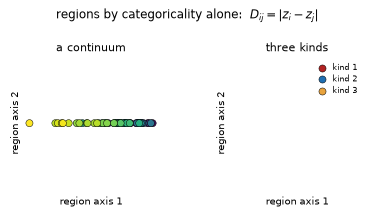

In [9]:
emb_z = {name: R.pca_embed(np.abs(r["z"][:, None] - r["z"][None, :]), 2)
         for name, r in res.items()}

for name, E in emb_z.items():
    print(f"{name:>10}: axis 1 spread {E[:, 0].std():.3f}   "
          f"axis 2 spread {E[:, 1].std():.1e}  (zero by construction)")

rz = stats.spearmanr(res["continuum"]["colour"], emb_z["continuum"][:, 0])
rp = stats.spearmanr(res["continuum"]["colour"], res["continuum"]["emb"][:, 0])
print(f"\ncontinuum: |rho(axis 1, position)|   categoricality {abs(rz.statistic):.2f}"
      f"   vs Procrustes {abs(rp.statistic):.2f}")

c, E = res["kinds"]["colour"], emb_z["kinds"]
sep = np.mean([abs(E[c == i, 0].mean() - E[c == j, 0].mean())
               for i in range(R.N_KINDS) for j in range(i + 1, R.N_KINDS)])
within = np.mean([E[c == k, 0].std() for k in range(R.N_KINDS)])
print(f"kinds    : centroid separation {sep:.3f} vs within-kind spread {within:.3f}"
      "   -> the kinds overlap")

fig, axes = plt.subplots(1, 2, figsize=(2 * PANEL, PANEL))
for ax, (name, r) in zip(axes, res.items()):
    E = emb_z[name]
    if name == "continuum":
        ax.scatter(E[:, 0], E[:, 1], c=r["colour"], cmap="viridis", s=26,
                   edgecolor="black", linewidths=0.35)
        ax.set_title("a continuum", fontsize=8, pad=3)
    else:
        for k in range(R.N_KINDS):
            m = r["colour"] == k
            ax.scatter(E[m, 0], E[m, 1], c=KIND_COLORS[k], s=26,
                       edgecolor="black", linewidths=0.35, label=f"kind {k + 1}")
        ax.legend(frameon=False, fontsize=6, loc="upper right", handlelength=1.0,
                  scatterpoints=1, labelspacing=0.3)
        ax.set_title("three kinds", fontsize=8, pad=3)
    # axis 2 is numerically zero, so fix the y range rather than let it
    # autoscale on noise: the flat line IS the result
    span = E[:, 0].max() - E[:, 0].min()
    ax.set(xticks=[], yticks=[], ylim=(-0.35 * span, 0.35 * span))
    ax.set_xlabel("region axis 1", fontsize=7.5)
    ax.set_ylabel("region axis 2", fontsize=7.5, labelpad=2)
    ax.set_box_aspect(1)
    sns.despine(ax=ax, left=True, bottom=True)

fig.suptitle("regions by categoricality alone:  $D_{ij} = |z_i - z_j|$", fontsize=8.5)
fig.tight_layout(w_pad=1.6)
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_z_embedding.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

## The example regions as population manifolds

The same four example regions, seen the other way round. Each region's activity is a
$120 \times 100$ matrix (values of $\theta$ by neurons); projecting the $120$ conditions onto
that region's own first three principal components traces its population manifold -- the
object a Procrustes distance actually compares.

/var/folders/y6/fg8mzc992tl23957x6w03yyh0000gn/T/ipykernel_13703/1059917897.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(w_pad=0.5)


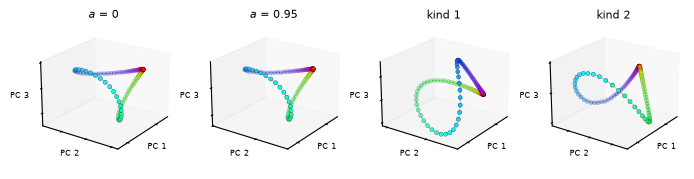

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)
from sklearn.decomposition import PCA

# the four example regions of the combined figure
PSI_R1 = R.PSI
KP = np.linspace(-R.PSI, R.PSI, R.N_KINDS)
ex_a, ex_psi = [0.0, 0.95, 0.0, 0.0], [PSI_R1, PSI_R1, KP[0], KP[1]]
etit = ["$a$ = 0", "$a$ = 0.95", "kind 1", "kind 2"]
Xe, rege = R.simulate(ex_a, ex_psi, seed=1)

fig = plt.figure(figsize=(4 * PANEL, 1.15 * PANEL))
for i in range(4):
    Xi = Xe[rege == i]                       # neurons x theta-bins
    # conditions as samples: the manifold traced out as theta varies
    M = PCA(3).fit_transform(Xi.T - Xi.T.mean(0))
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    ax.plot(M[:, 0], M[:, 1], M[:, 2], color="0.7", lw=0.6, zorder=1)
    ax.scatter(M[:, 0], M[:, 1], M[:, 2], c=np.degrees(R.THETAS), cmap="hsv",
               s=9, edgecolor="black", linewidths=0.2, zorder=2)
    ax.set_title(etit[i], fontsize=8, pad=0)
    for a_, lab in ((ax.xaxis, "PC 1"), (ax.yaxis, "PC 2"), (ax.zaxis, "PC 3")):
        a_.set_ticklabels([]); a_.set_tick_params(length=0)
    ax.set_xlabel("PC 1", fontsize=6, labelpad=-12)
    ax.set_ylabel("PC 2", fontsize=6, labelpad=-12)
    ax.set_zlabel("PC 3", fontsize=6, labelpad=-12)
    ax.grid(False)
    ax.view_init(elev=22, azim=35)

fig.tight_layout(w_pad=0.5)
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_manifolds.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()

## The example regions as a PCA of the neurons

The four example regions of the summary figure again, but with the plane *measured* rather
than assumed. The summary figure places each neuron by its shape coordinates, which are
recovered by projecting onto the modes the curves were built from -- it uses the generator.
Here the neurons $\times$ conditions matrix is simply handed to PCA and each neuron is
plotted by its first two scores, with nothing about the generator assumed.

One plane is fitted to all four regions pooled, so the four panels share axes and are
directly comparable; fitting each region separately would give each panel its own arbitrary
rotation. The dashed line is each region's own long axis, measured as the leading
eigenvector of its neurons' covariance -- so the change in its orientation between the
bottom two panels is the change in $\psi$, read off the data.

variance explained by 2 PCs: 99.95 %   (the generator spans exactly two dimensions, plus noise)
shape coordinates recovered from the PCA scores: R^2 = 0.9981


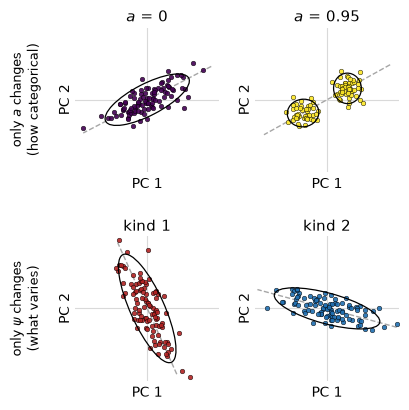

In [11]:
# Xe, rege, ex_psi and etit come from the manifold cell above; PCA is imported there.
P_TITLE, P_LABEL, P_ANNOT = 11, 10, 9

Ye_all = PCA(2).fit(Xe)
Ye = Ye_all.transform(Xe)
print(f"variance explained by 2 PCs: {100 * Ye_all.explained_variance_ratio_.sum():.2f} %"
      "   (the generator spans exactly two dimensions, plus noise)")

# the PCA plane is the shape-mode plane up to a rotation: check it recovers the
# same neuron ordering rather than merely looking similar
Wchk = shape_coords(Xe)
canon = np.linalg.lstsq(Ye, Wchk, rcond=None)[0]          # best linear map PCA -> shape
resid = 1 - np.sum((Wchk - Ye @ canon) ** 2) / np.sum((Wchk - Wchk.mean(0)) ** 2)
print(f"shape coordinates recovered from the PCA scores: R^2 = {resid:.4f}")

pcl = [Ye[rege == i] - Ye[rege == i].mean(0) for i in range(4)]
plim = 1.12 * np.percentile(np.abs(np.concatenate(pcl)), 99.5)
pcols = [plt.get_cmap("viridis")(0.0), plt.get_cmap("viridis")(1.0),
         KIND_COLORS[0], KIND_COLORS[1]]
prow = ["only $a$ changes\n(how categorical)", "only $\\psi$ changes\n(what varies)"]

fig, axes = plt.subplots(2, 2, figsize=(2 * PANEL, 2 * PANEL))
for i, ax in enumerate(axes.ravel()):
    P = pcl[i]
    # the region's long axis, measured from its own neurons
    w_, V_ = np.linalg.eigh(np.cov(P, rowvar=False))
    u = V_[:, -1]
    ax.axhline(0, color="0.85", lw=0.8, zorder=0)
    ax.axvline(0, color="0.85", lw=0.8, zorder=0)
    ax.plot([-plim * u[0], plim * u[0]], [-plim * u[1], plim * u[1]],
            color="0.65", lw=1, ls="--", zorder=1)
    ax.scatter(P[:, 0], P[:, 1], s=11, facecolor=pcols[i], edgecolor="black",
               linewidths=0.35, alpha=0.9, zorder=2)
    # same convention as the summary figure: one 2-s.d. ellipse, except at
    # a = 0.95 where the two lobes are fitted separately
    if i == 1:
        proj = P @ u
        for m in (proj < 0, proj >= 0):
            gauss_ellipse(ax, P[m])
    else:
        gauss_ellipse(ax, P)
    ax.set(xlim=(-plim, plim), ylim=(-plim, plim), xticks=[], yticks=[])
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2", labelpad=2)
    ax.set_title(etit[i], pad=4)
    ax.set_box_aspect(1)
    sns.despine(ax=ax, left=True, bottom=True)

for row in (0, 1):
    axes[row, 0].text(-0.34, 0.5, prow[row], rotation=90, va="center",
                      ha="center", transform=axes[row, 0].transAxes,
                      fontsize=P_ANNOT)

# this figure sets its own sizes: it is a quarter the width of the summary
# figure, so it does not follow that figure's scale
for ax in axes.ravel():
    ax.title.set_fontsize(P_TITLE)
    ax.xaxis.label.set_fontsize(P_LABEL)
    ax.yaxis.label.set_fontsize(P_LABEL)

fig.tight_layout(w_pad=1.4, h_pad=2.0)
for e in ("svg", "pdf", "png"):
    fig.savefig(OUT / f"region_examples_pca.{e}", bbox_inches="tight",
                dpi=300 if e == "png" else None)
plt.show()